In [11]:
import sys
from matplotlib import pyplot as plt
import numpy as np

plt.rc("font", size = 14)
plt.rc("axes", labelsize = 14, titlesize = 14)

plt.rc("legend", fontsize = 14)
plt.rc("xtick", labelsize = 10)
plt.rc("ytick", labelsize = 10)

from pathlib import Path
IMAGES_PATH = Path() /"images"/"training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution = 300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)



In [12]:
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3*X + np.random.rand(m, 1)

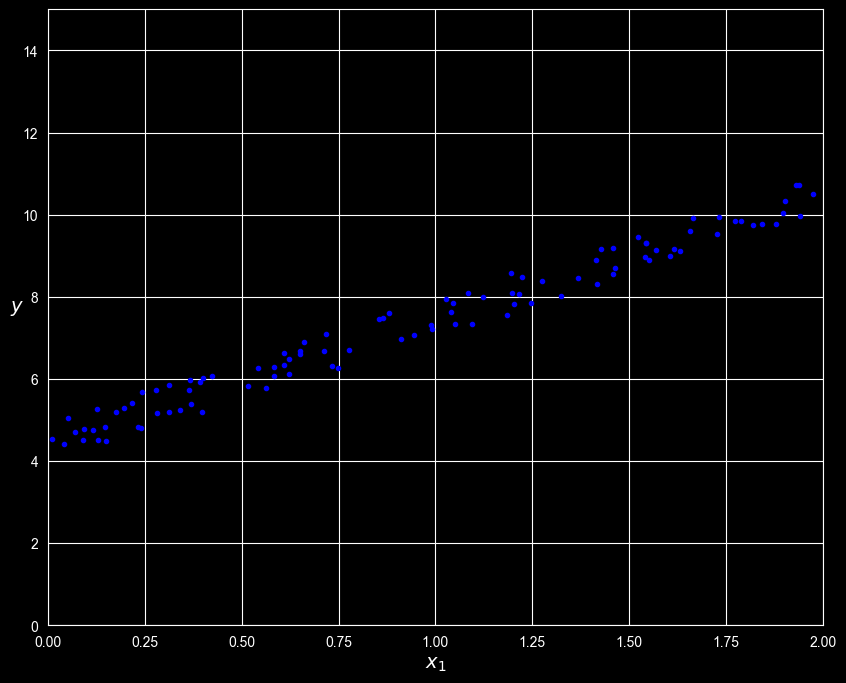

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(10,8))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid(True)
plt.show()
save_fig("generated_data_plot")
plt.show()

now lets use Normal equation to get the THeta cap

In [15]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [16]:
theta_best

array([[4.51359766],
       [2.98323418]])

In [17]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 4.51359766],
       [10.48006601]])

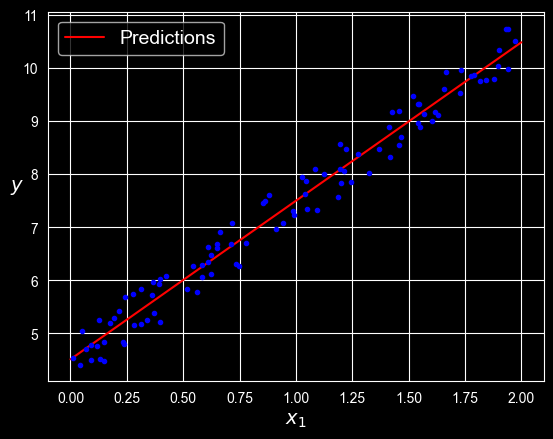

<Figure size 640x480 with 0 Axes>

In [20]:
plt.plot(X_new,y_predict, "r-", label ="Predictions")
plt.plot(X,y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.show()
save_fig("linear_regression_plot")

# We can do the same thing with SciketLearn and its way easier

In [24]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_ # bias term , weights

(array([4.51359766]), array([[2.98323418]]))

In [23]:
lin_reg.predict(X_new)

array([[ 4.51359766],
       [10.48006601]])

LinearRegression class is based on the
scipy.linalg.lstsq() function ( “least squares”)

In [25]:
theta_best_svd , residuals , rank , s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[4.51359766],
       [2.98323418]])

In [26]:
np.linalg.pinv(X_b) @ y
#Both give the best theta

array([[4.51359766],
       [2.98323418]])

# Gradient Descent